<a href="https://colab.research.google.com/github/NamithaDaney/Classification/blob/main/Assignment_07_Classification_Algorithms_Model_Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Dataset:
Use the breast cancer dataset available in the sklearn library.
####Key components to be fulfilled:
Loading and Preprocessing (2 marks):


* Load the breast cancer dataset from sklearn.
* Preprocess the data to handle any missing values and perform necessary feature scaling.
* Explain the preprocessing steps you performed and justify why they are
necessary for this dataset.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score

In [ ]:
#Load the breast cancer dataset
data = load_breast_cancer()

# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
#check null values
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
mean radius,456
mean texture,479
mean perimeter,522
mean area,539
mean smoothness,474
mean compactness,537
mean concavity,537
mean concave points,542
mean symmetry,432
mean fractal dimension,499


In [ ]:
df.shape

(569, 31)

####Classification Algorithm Implementation:
Implement the following five classification algorithms:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. k-Nearest Neighbors (k-NN)

For each algorithm, provide a brief description of how it works and why it might be suitable for this dataset.

In [ ]:
X = df.drop('target', axis=1)
y = pd.Series(data.target)

In [ ]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
y

,0
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#standardization
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

We first check for null values and duplicate rows to ensure the dataset is clean and free of repetitive data that could bias our model. Finally, we standardize all features using a StandardScaler so that variables with large numbers, do not mathematically overwhelm smaller numbers.

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression()
log_reg_model.fit(x_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_predict = log_reg_model.predict(x_test_scaled)
y_predict

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [ ]:
#Accuracy
print('Baseline Accuracy',accuracy_score(y_test,y_predict))

Baseline Accuracy 0.9736842105263158


In [ ]:
#classification_report
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
#confusion_matrix
cm = confusion_matrix(y_test,y_predict)
cm


array([[41,  2],
       [ 1, 70]])

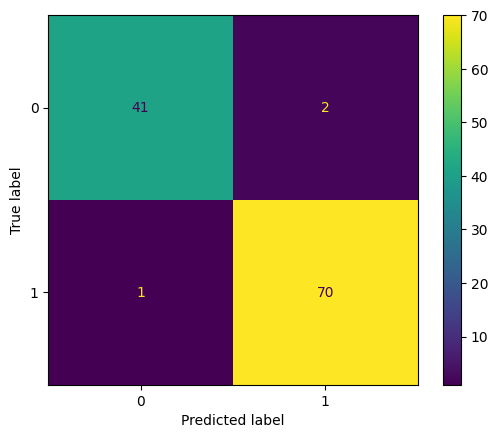

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
dis = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=log_reg_model.classes_)
dis.plot()

In [ ]:
# Construct a pipeline to encapsulate scaling and modeling
from sklearn.pipeline import Pipeline
pipe=Pipeline([('scaler',StandardScaler()),('lr',LogisticRegression())])

In [ ]:
base=pipe.fit(x_train,y_train)
pred=base.predict(x_test)
print(f'Baseline Accuracy :{accuracy_score(y_test,pred):.4f}') #f1_score(y_test, gp_knn_rand):.4f
print(f'Cross Value: {cross_val_score(pipe,X,y,cv=5).mean():.4f}')

print('\nClassification Report')
print(classification_report(y_test,pred))



Baseline Accuracy :0.9737
Cross Value: 0.9807

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
#GridSearch
param_grid={
'lr__C':[0.01,0.1,1,10,100],
'lr__penalty':['l2'],
'lr__solver':['lbfgs'],
'lr__max_iter':[200,500]
}

grid=GridSearchCV(pipe,param_grid,cv=5,scoring='f1')
grid.fit(x_train,y_train)
print(grid.best_params_)

gp=grid.predict(x_test)
print(f'Grid F1 :{f1_score(y_test,gp):.4f}')

{'lr__C': 10, 'lr__max_iter': 200, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Grid F1 :0.9787


In [ ]:
#RandomizedSearch
param_dist={
'lr__C':[0.001,0.01,0.1,1,10,100],
'lr__max_iter':[100,200,300,500]
}

rand=RandomizedSearchCV(pipe,param_dist,n_iter=6,cv=5,random_state=42,scoring='f1')
rand.fit(x_train,y_train)
print(rand.best_params_)

rp=rand.predict(x_test)
print(f'Random F1: {f1_score(y_test,rp):.4f}')

{'lr__max_iter': 100, 'lr__C': 10}
Random F1: 0.9787


In [ ]:
models={
'Baseline':base,
'GridSearch':grid.best_estimator_,
'RandomSearch':rand.best_estimator_
}
results=[]
for n,m in models.items():
    p=m.predict(x_test)
    results.append((n,round(accuracy_score(y_test,p),4),round(f1_score(y_test,p),4),round(float(roc_auc_score(y_test,m.predict_proba(x_test)[:,1])),4)))
print(results)


[('Baseline', 0.9737, 0.979, 0.9974), ('GridSearch', 0.9737, 0.9787, 0.9961), ('RandomSearch', 0.9737, 0.9787, 0.9961)]


In [ ]:
best=max(results,key=lambda x:(x[2],x[3]))
print('Best Model:',best)

Best Model: ('Baseline', 0.9737, 0.979, 0.9974)


Logistic Regression is a boundry-based model find optimal lines to split the data, which works perfectly here because the tumor classes have highly linear and distinct separation.

Here baseline of logistic regression performed better with accuracy of 97 per cent.

In [ ]:
'''for n,m in models.items():
  print(f"m is {m} and n is {n}")'''


m is Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression())]) and n is Baseline
m is Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(C=10, max_iter=200))]) and n is GridSearch
m is Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression(C=10))]) and n is RandomSearch


Decision Tree Classifier

In [ ]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
y_predict_dt = dt_model.predict(x_test_scaled)
y_predict_dt

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0])

In [ ]:
print('Baseline Accuracy :',accuracy_score(y_test,y_predict_dt))

print(classification_report(y_test,y_predict_dt))

Baseline Accuracy 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
cm_dt = confusion_matrix(y_test,y_predict_dt)
cm_dt

array([[40,  3],
       [ 3, 68]])

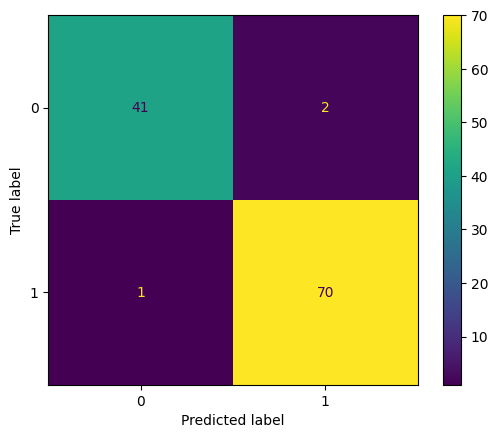

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
dis = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt_model.classes_)
dis.plot()

In [ ]:
# 3. Construct a pipeline to encapsulate scaling and modeling
from sklearn.pipeline import Pipeline

pipe_dt=Pipeline([('scaler',StandardScaler()),('dt',DecisionTreeClassifier())])

In [ ]:
base_dt=pipe_dt.fit(x_train,y_train)
pred_dt=base_dt.predict(x_test)

print('Baseline Accuracy',accuracy_score(y_test,pred_dt))
print(classification_report(y_test,pred_dt))

print(f'Cross Value = {cross_val_score(pipe_dt,X,y,cv=5).mean()}')

Baseline Accuracy 0.9385964912280702
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Cross Value = 0.9173886042539978


In [ ]:
#GridSearch
param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [3, 4, 5, 6, 8, 10, None],
    'dt__min_samples_split':[2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 5, 10]
}

grid_dt = GridSearchCV(pipe_dt,param_grid,cv=5,scoring='f1')
grid_dt.fit(x_train,y_train)
print(grid_dt.best_params_)

gp_dt = grid_dt.predict(x_test)
print('Grid F1',f1_score(y_test,gp_dt))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, gp_dt))

{'dt__criterion': 'entropy', 'dt__max_depth': 6, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 10}
Grid F1 0.9583333333333334

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [130]:
#RandomizedSearch
from scipy.stats import randint
param_distributions = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': randint(2, 20),
    'dt__min_samples_split': randint(2, 30),
    'dt__min_samples_leaf': randint(1, 20)
}

rand_dt=RandomizedSearchCV(pipe_dt,param_distributions,n_iter=6,cv=5,random_state=42,scoring='f1')
rand_dt.fit(x_train,y_train)
print(rand_dt.best_params_)

rp_dt=rand.predict(x_test)
print('Random F1 :',round(f1_score(y_test,rp_dt),4))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, rp_dt))


{'dt__criterion': 'entropy', 'dt__max_depth': 4, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 25}
Random F1 : 0.9787

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [132]:
models={
'Baseline':base_dt,
'GridSearch':grid_dt.best_estimator_,
'RandomSearch':rand_dt.best_estimator_
}
results=[]
for n,m in models.items():
    p=m.predict(x_test)
    results.append((n,round(accuracy_score(y_test,p),4),round(f1_score(y_test,p),4),round(float(roc_auc_score(y_test,m.predict_proba(x_test)[:,1])),4)))
print(results)

#best model
best=max(results,key=lambda x:(x[2],x[3]))
print('Best Model:',best)

[('Baseline', 0.9386, 0.951, 0.9324), ('GridSearch', 0.9474, 0.9583, 0.9453), ('RandomSearch', 0.9561, 0.9655, 0.9663)]
Best Model: ('RandomSearch', 0.9561, 0.9655, 0.9663)


Decision Trees is a Tree-Based Model. It split data step-by-step based on feature rules to capture complex interactions without needing complex math setups.

Random Serach of Decision Tree performed better here with the f1_score of 96 per cent.

Random Forest Classifier

In [ ]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(x_train_scaled,y_train)

RandomForestClassifier()

In [ ]:
y_predict_rf = rf_model.predict(x_test_scaled)
y_predict_rf

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [135]:
print('Baseline Accuracy :',round(accuracy_score(y_test,y_predict_rf),4))
print('Baseline f1 :',round(f1_score(y_test,y_predict_rf),4))
print("\nClassification Report")
print(classification_report(y_test,y_predict_rf))

Baseline Accuracy : 0.9649
Baseline f1 : 0.9722

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
cm_rf = confusion_matrix(y_test,y_predict_dt)
cm_rf

array([[40,  3],
       [ 3, 68]])

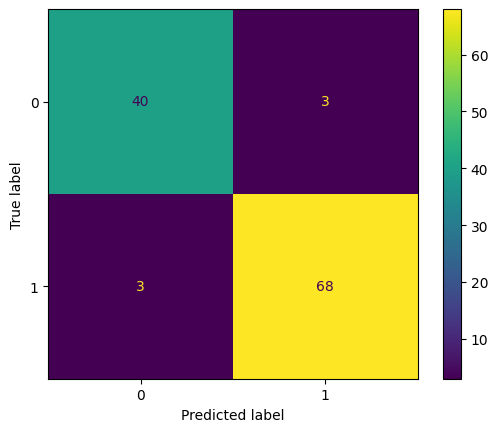

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
dis = ConfusionMatrixDisplay(confusion_matrix=cm_rf,display_labels=rf_model.classes_)
dis.plot()

In [138]:
pipe_rf = Pipeline([('scaler', StandardScaler()),('rf', RandomForestClassifier(random_state=42))])

base_rf=pipe_rf.fit(x_train,y_train)
pred_rf=base_rf.predict(x_test)

print('Baseline Accuracy: ',round(accuracy_score(y_test,pred_rf),4))
print('Baseline F1: ',round(f1_score(y_test,pred_rf),4))
print("\nClassification Report")
print(classification_report(y_test,pred_rf))

print(f'Cross Value = {cross_val_score(pipe_rf,X,y,cv=5).mean():.4f}')

Baseline Accuracy:  0.9649
Baseline F1:  0.9722

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Cross Value = 0.9561


In [139]:
param_rf = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [8,10, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2', None]
}

grid_rf = GridSearchCV(pipe_rf,param_rf,cv=5,scoring='f1')
grid_rf.fit(x_train,y_train)
print(grid_rf.best_params_)

gp_rf = grid_rf.predict(x_test)
print('Grid F1 :',round(f1_score(y_test,gp_rf),4))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, gp_rf))

{'rf__max_depth': 8, 'rf__max_features': 'log2', 'rf__min_samples_split': 5, 'rf__n_estimators': 50}
Grid F1 : 0.979

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [140]:
param_rf_rand = {
    'rf__n_estimators': [50, 100,200],
    'rf__max_depth': [3, 4, 5, 6, 8, None],
    'rf__min_samples_split': [2,5,10],
    'rf__max_features': ['sqrt', 'log2', None]
}

rand_rf = RandomizedSearchCV(pipe_rf,param_rf_rand,n_iter=20,scoring='f1',n_jobs=-1,random_state=42)
rand_rf.fit(x_train,y_train)
print(rand_rf.best_params_)

rp_rf = rand_rf.predict(x_test)
print('Random F1 :',round(f1_score(y_test,rp_rf),4))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, gp_rf))

{'rf__n_estimators': 100, 'rf__min_samples_split': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 5}
Random F1 : 0.9722

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [141]:
models={
'Baseline':base_rf,
'GridSearch':grid_rf.best_estimator_,
'RandomSearch':rand_rf.best_estimator_
}
results=[]
for n,m in models.items():
    p=m.predict(x_test)
    results.append((n,round(accuracy_score(y_test,p),4),round(f1_score(y_test,p),4),round(float(roc_auc_score(y_test,m.predict_proba(x_test)[:,1])),4)))
print(results)

#best model
best=max(results,key=lambda x:(x[2],x[3]))
print('Best Model:',best)

[('Baseline', 0.9649, 0.9722, 0.9953), ('GridSearch', 0.9737, 0.979, 0.9974), ('RandomSearch', 0.9649, 0.9722, 0.9964)]
Best Model: ('GridSearch', 0.9737, 0.979, 0.9974)


Random Forests is a Tree-Based Model. It split data step-by-step based on feature rules to capture complex interactions without needing complex math setups.

Here GridSearch of Random Forest performed the best with accuracy of 97 per cent.

Support Vector Machine (SVM)

In [ ]:
#Support Vector Machine (SVM)
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(x_train_scaled,y_train)

SVC()

In [ ]:
y_predict_svc = svm_model.predict(x_test_scaled)
y_predict_svc

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [143]:
print('Baseline Accuracy :',round(accuracy_score(y_test,y_predict_svc),4))
print('Baseline f1 :',round(f1_score(y_test,y_predict_svc),4))
print("\nClassification Report")
print(classification_report(y_test,y_predict_svc))

Baseline Accuracy : 0.9825
Baseline f1 : 0.9861

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
cm_svc = confusion_matrix(y_test,y_predict_svc)
cm_svc

array([[41,  2],
       [ 0, 71]])

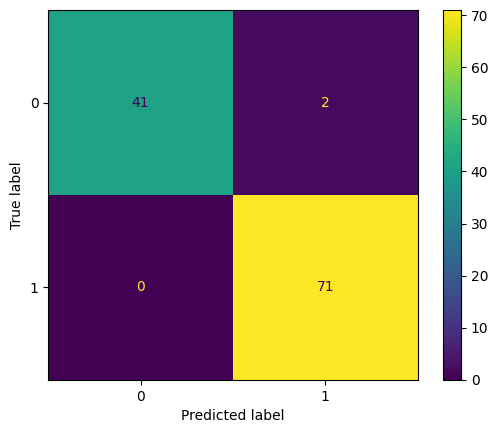

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
dis = ConfusionMatrixDisplay(confusion_matrix=cm_svc,display_labels=svm_model.classes_)
dis.plot()

In [145]:
pipe_svm = Pipeline([('scaler', StandardScaler()),('svm', SVC(probability=True, random_state=42))])

base_svm=pipe_svm.fit(x_train,y_train)
pred_svm=base_svm.predict(x_test)

print('Baseline Accuracy: ',round(accuracy_score(y_test,pred_svm),4))
print('Baseline F1: ',round(f1_score(y_test,pred_svm),4))
print("\nClassification Report")
print(classification_report(y_test,pred_svm))

print(f'Cross Value = {cross_val_score(pipe_svm,X,y,cv=5).mean():.4f}')

Baseline Accuracy:  0.9825
Baseline F1:  0.9861

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Cross Value = 0.9736


In [146]:
#GridSerach
param_svm_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'svm__kernel': ['rbf', 'poly'],
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    }
]

grid_svm = GridSearchCV(pipe_svm, param_svm_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(x_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)

#Evaluate predictions
gp_svm = grid_svm.predict(x_test)
print('Grid F1:', round(f1_score(y_test, gp_svm),4))
print("\nFinal Test Classification Report:")
print(classification_report(y_test, gp_svm))

Best SVM Params: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Grid F1: 0.9861

Final Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [148]:
#Randomized Search
param_svm_rand = {
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

rand_svm = RandomizedSearchCV(pipe_svm,param_svm_rand,n_iter=30,cv=5,scoring='f1',n_jobs=-1,random_state=42)
rand_svm.fit(x_train,y_train)
print(rand_svm.best_params_)

rp_svm = rand_svm.predict(x_test)
print('Random F1 : ',round(f1_score(y_test,rp_svm),4))

{'svm__kernel': 'rbf', 'svm__gamma': 'auto', 'svm__C': 1}
Random F1 :  0.9861


In [149]:
models={
'Baseline':base_svm,
'GridSearch':grid_svm.best_estimator_,
'RandomSearch':rand_svm.best_estimator_
}
results=[]
for n,m in models.items():
    p=m.predict(x_test)
    results.append((n,round(accuracy_score(y_test,p),4),round(f1_score(y_test,p),4),round(float(roc_auc_score(y_test,m.predict_proba(x_test)[:,1])),4)))
print(results)

#best model
best=max(results,key=lambda x:(x[2],x[3]))
print('Best Model:',best)

[('Baseline', 0.9825, 0.9861, 0.9974), ('GridSearch', 0.9825, 0.9861, 0.9971), ('RandomSearch', 0.9825, 0.9861, 0.9974)]
Best Model: ('Baseline', 0.9825, 0.9861, 0.9974)


Support Vector Machine(SVM) is a Boundary-based models it find optimal lines to split the data, which works perfectly here because the tumor classes have highly linear and distinct separation.

Here Baseline model gives higher accuracy of 98 per cent.

k-Nearest Neighbors (k-NN)

In [ ]:
#k-Nearest Neighbors (k-NN)

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(x_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_predict_knn = knn_model.predict(x_test_scaled)
y_predict_knn

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [ ]:
print('Baseline Accuracy :',accuracy_score(y_test,y_predict_knn))
print('Baseline f1 :',f1_score(y_test,y_predict_knn))
print(classification_report(y_test,y_predict_knn))

Baseline Accuracy : 0.9473684210526315
Baseline f1 : 0.9577464788732394
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
cm_knn = confusion_matrix(y_test,y_predict_knn)
cm_knn

array([[40,  3],
       [ 3, 68]])

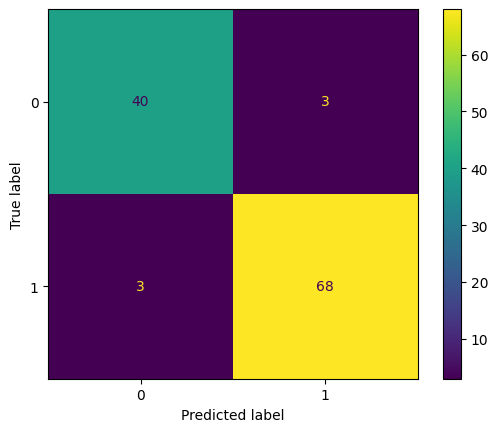

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
dis = ConfusionMatrixDisplay(confusion_matrix=cm_knn,display_labels=knn_model.classes_)
dis.plot()

In [151]:
pipe_knn = Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier())])

base_knn=pipe_knn.fit(x_train,y_train)
pred_knn=base_knn.predict(x_test)

print('Baseline Accuracy: ',round(accuracy_score(y_test,pred_knn),4))
print('Baseline F1: ',round(f1_score(y_test,pred_knn),4))
print("\nClassification Report")
print(classification_report(y_test,pred_knn))

print(f'Cross Value = {cross_val_score(pipe_knn,X,y,cv=5).mean():.4}')

Baseline Accuracy:  0.9474
Baseline F1:  0.9577

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Cross Value = 0.9649


In [152]:
#GridSearchCV
param_knn_grid = {
    'knn__n_neighbors': list(range(3, 31, 2)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipe_knn, param_knn_grid, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(x_train, y_train)

print("Best KNN Params:", grid_knn.best_params_)

#Evaluate predictions
gp_knn = grid_knn.predict(x_test)
print('Grid F1:', round(f1_score(y_test, gp_knn),4))
print("\nFinal Test Classification Report:")
print(classification_report(y_test, gp_knn))




Best KNN Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Grid F1: 0.9718

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [153]:
#RandomizedSearchCV

param_knn_rand = {
    'knn__n_neighbors': randint(3, 31),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

rand_knn = RandomizedSearchCV(pipe_knn,param_knn_rand,n_iter=15,cv=5,scoring='f1',n_jobs=-1,random_state=42)
rand_knn.fit(x_train,y_train)
print(rand_knn.best_params_)

rp_knn = rand_knn.predict(x_test)
print('Random F1 :',round(f1_score(y_test,rp_knn),4))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, rp_knn))

{'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Random F1 : 0.9718

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [154]:
models={
'Baseline':base_knn,
'GridSearch':grid_knn.best_estimator_,
'RandomSearch':rand_knn.best_estimator_
}
results=[]
for n,m in models.items():
    p=m.predict(x_test)
    results.append((n,round(accuracy_score(y_test,p),4),round(f1_score(y_test,p),4),round(float(roc_auc_score(y_test,m.predict_proba(x_test)[:,1])),4)))
print(results)

#best model
best=max(results,key=lambda x:(x[2],x[3]))
print('Best Model:',best)

[('Baseline', 0.9474, 0.9577, 0.982), ('GridSearch', 0.9649, 0.9718, 0.9831), ('RandomSearch', 0.9649, 0.9718, 0.984)]
Best Model: ('RandomSearch', 0.9649, 0.9718, 0.984)


K-Nearest Neighbors (KNN) simply looks at the closest surrounding data points to make a decision, which is highly effective because similar tumor profiles naturally cluster together in space.

Here Random Search of K-Nearest Neighbors gave best performance of accuracy 96 per cent.

In [ ]:
#Find the best model among these entire different models results

models = {
    'Baseline_LogReg': base,
    'RandomSearch_DecisionTree': rand_dt.best_estimator_,
    'GridSearch_Rainforest': grid_rf.best_estimator_,
    'Baseline_SVM': base_svm,
    'RandomSearch_KNN': rand_knn.best_estimator_
}

results = []
for n, m in models.items():
    p = m.predict(x_test)
    results.append((n, accuracy_score(y_test, p), f1_score(y_test, p), float(roc_auc_score(y_test, m.predict_proba(x_test)[:, 1]))))


df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1-Score', 'ROC-AUC'])
print(df_results.to_string(index=False))

# Select absolute best model using F1-score as primary and AUC as tie-breaker
best = max(results, key=lambda x: (x[2], x[3]))
print('\n Absolute Best Model:', best[0])

                    Model  Accuracy  F1-Score  ROC-AUC
          Baseline_LogReg  0.973684  0.979021  0.99738
RandomSearch_DecisionTree  0.964912  0.972603  0.96790
    GridSearch_Rainforest  0.973684  0.979021  0.99738
             Baseline_SVM  0.982456  0.986111  0.99738
         RandomSearch_KNN  0.964912  0.971831  0.98395

 Absolute Best Model: Baseline_SVM


Baseline_SVM performed the best because it achieved the highest accuracy (98.25%) and F1-score (98.61%) by drawing an optimal maximum-margin boundary between classes.

RandomSearch_KNN scored the lowest,but it is important to highlight that all five models performed well with outstanding scores.Every single algorithm captured an Accuracy and F1-Score well above 96%, proving that all of these configurations are highly capable and reliable for this dataset.